In [1]:
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import StepLR
from torch.optim.lr_scheduler import ReduceLROnPlateau

from models.vae_gpt import *
from train.trainer.Trainer_GPT import Trainer
from data.preprocessing.pipeline import Pipeline
from data.datasets.universal_dataset import CVADataset
from data.preprocessing.splitter import select_test_inh
from utils.paths import get_project_path

import os

In [2]:
def load_data(drop_inhib: str):
    prep = Pipeline(
        num_cycle=[1, 2, 3, 4], 
        inhibitor_name="all", 
        split="all",
        norm_feat=True
    )
    data = prep.full_data

    train_data, valid_data = select_test_inh(data, drop_inhib)
    
    return train_data, valid_data

In [ ]:
INHIBITOR_NAME = "2-mercaptobenzimidazole"
normalize = False

train, val = load_data(drop_inhib=INHIBITOR_NAME)

train_dataset = CVADataset(train, normalize=normalize)
test_dataset = CVADataset(val, normalize=normalize)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

In [ ]:
if torch.cuda.is_available():
    device = "cuda:0"
else:
    device = "cpu"

vae = GPT(
    cond_dim=41,
    seq_len=968,
    d_model=64,
    nhead=1,
    num_layers=1,
    dropout=0.3
).to(device)

opt_vae = torch.optim.Adam(vae.parameters(), lr=1e-3)
scheduler = StepLR(opt_vae, step_size=50, gamma=0.15)

train_denormalize_fn = None
val_denormalize_fn = None

if normalize:
    train_denormalize_fn = train_dataset.denormalize
    val_denormalize_fn = test_dataset.denormalize

/home/smirnov@dohod.local/Desktop/electrochem-digital-twins/.venv/lib/python3.13/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [ ]:
vae.y_start_emb

Parameter containing:
tensor([[ 0.0018,  0.0051,  0.0136, -0.0010,  0.0042,  0.0041,  0.0089,  0.0168,
         -0.0117, -0.0102,  0.0230,  0.0168,  0.0087, -0.0119, -0.0007, -0.0039,
         -0.0022, -0.0034, -0.0006, -0.0036, -0.0069, -0.0044,  0.0053,  0.0044,
          0.0050, -0.0206,  0.0209,  0.0025, -0.0198,  0.0113, -0.0060,  0.0164,
         -0.0126,  0.0094, -0.0107, -0.0014,  0.0148, -0.0134,  0.0161,  0.0068,
          0.0006, -0.0093, -0.0066,  0.0081,  0.0064, -0.0230,  0.0199,  0.0040,
         -0.0149, -0.0062, -0.0040, -0.0097,  0.0124, -0.0013, -0.0051, -0.0071,
         -0.0027, -0.0033, -0.0170,  0.0005, -0.0143,  0.0156,  0.0166, -0.0239]],
       device='cuda:0', requires_grad=True)

In [ ]:
num_epoch = 251

trainer = Trainer(
    model=vae,
    loss_fn=vae_loss,
    epochs=num_epoch,
    optimizer=opt_vae,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    path_to_save_plots=os.path.join(get_project_path(), "reports", "gpt", INHIBITOR_NAME),
    path_to_save_models=os.path.join(get_project_path(), "models", "gpt", INHIBITOR_NAME, "best_model.pt"),
    path_to_save_tables=os.path.join(get_project_path(), "reports", "gpt", INHIBITOR_NAME),
    scheduler=scheduler,
    train_denorm_fn=train_denormalize_fn,
    val_denorm_fn=val_denormalize_fn,
    seed=42
)

In [ ]:
trainer.train_model()

Epoch 000 — Train Loss: 0.790167, Val Loss: 0.576094
Epoch 001 — Train Loss: 0.627386, Val Loss: 0.472084
Epoch 002 — Train Loss: 0.519482, Val Loss: 0.380362
Epoch 003 — Train Loss: 0.430059, Val Loss: 0.318308
Epoch 004 — Train Loss: 0.363867, Val Loss: 0.281668
Epoch 005 — Train Loss: 0.319067, Val Loss: 0.253970
Epoch 006 — Train Loss: 0.283762, Val Loss: 0.225293
Epoch 007 — Train Loss: 0.252433, Val Loss: 0.197955
Epoch 008 — Train Loss: 0.224479, Val Loss: 0.174436
Epoch 009 — Train Loss: 0.199749, Val Loss: 0.154650
Epoch 010 — Train Loss: 0.178315, Val Loss: 0.137687
Epoch 011 — Train Loss: 0.159716, Val Loss: 0.122951
Epoch 012 — Train Loss: 0.143692, Val Loss: 0.110592
Epoch 013 — Train Loss: 0.130025, Val Loss: 0.100120
Epoch 014 — Train Loss: 0.118379, Val Loss: 0.091161
Epoch 015 — Train Loss: 0.108369, Val Loss: 0.083312
Epoch 016 — Train Loss: 0.099714, Val Loss: 0.076431
Epoch 017 — Train Loss: 0.092252, Val Loss: 0.070389
Epoch 018 — Train Loss: 0.085583, Val Loss: 0.

In [ ]:
vae.y_start_emb

Parameter containing:
tensor([[ 0.0103,  0.0118,  0.0093,  0.0127,  0.0049,  0.0159,  0.0056,  0.0118,
          0.0244, -0.0094,  0.0003, -0.0274, -0.0070, -0.0011, -0.0187,  0.0097,
          0.0086, -0.0045, -0.0017,  0.0055, -0.0156, -0.0215, -0.0055,  0.0220,
          0.0133,  0.0107, -0.0226, -0.0291,  0.0049, -0.0041, -0.0068, -0.0156,
          0.0009,  0.0043,  0.0035, -0.0070, -0.0019, -0.0080,  0.0007, -0.0023,
          0.0050, -0.0022, -0.0048, -0.0055,  0.0179, -0.0117,  0.0053,  0.0029,
         -0.0039,  0.0048, -0.0042,  0.0026, -0.0065,  0.0011,  0.0051,  0.0159,
          0.0041, -0.0018, -0.0020, -0.0032, -0.0047,  0.0028, -0.0075, -0.0004]],
       device='cuda:0', requires_grad=True)

In [ ]:
import matplotlib.pyplot as plt

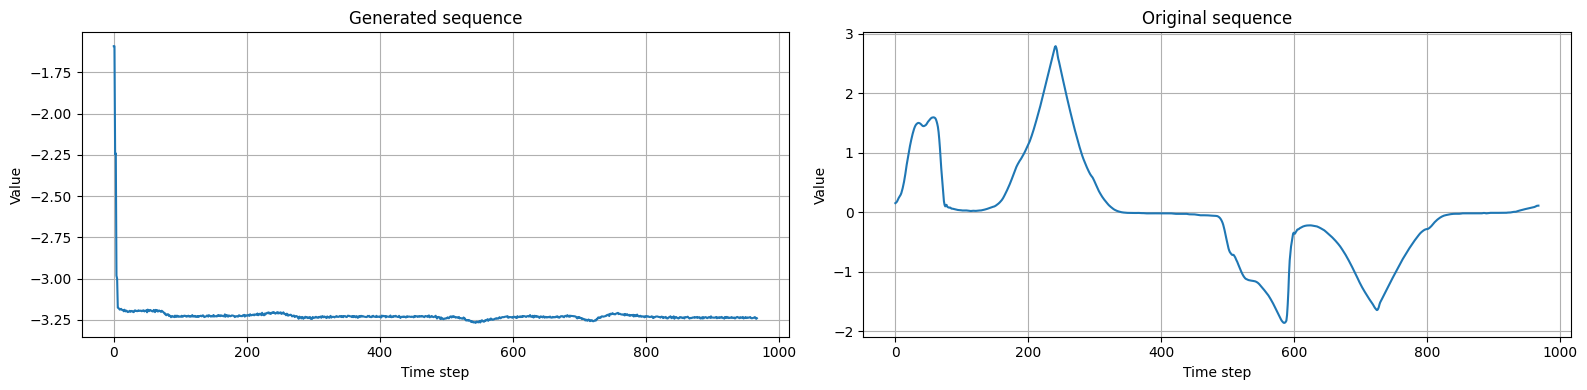

In [ ]:
generated_seq = vae.generate(test_dataset[0]['features'].unsqueeze(0).to(device)).squeeze(0).cpu().numpy()  # [968]
test_seq = test_dataset[0]['vah'].cpu().numpy()

fig, axs = plt.subplots(1, 2, figsize=(16, 4))

axs[0].plot(generated_seq)
axs[0].set_title("Generated sequence")
axs[0].set_xlabel("Time step")
axs[0].set_ylabel("Value")
axs[0].grid(True)

axs[1].plot(test_seq)
axs[1].set_title("Original sequence")
axs[1].set_xlabel("Time step")
axs[1].set_ylabel("Value")
axs[1].grid(True)

plt.tight_layout()
plt.show()